# Barley iMAGIC

|                        |                                                      |
| ---------------------- | ---------------------------------------------------- |
| **Crop**               | Barley                                               |
| **Location**           | Wollo/Geregera & Gondar/Dabat, Ethiopia              |
| **Year**               | 2022–2023                                            |
| **Measurements**       | 13,178                                               |
| **Genotypes**          | 508 genotypes (74% coverage)                         |
| **Owner**              | Matteo Dell'Acqua (Scuola Superiore Sant'Anna, Pisa) |
| **Protocol**           | Photosynthesis RIDES 2.0                             |
| **PhotosynQ projects** | 17237, 17238, 18685, 19236                           |

**Experiment:** Photosynthesis phenotyping of the iMAGIC (International Multi-parent Advanced Generation Inter-Cross) barley population in Ethiopia, part of the CAPITALISE project. Measurements collected across two locations and two replications per location. The iMAGIC population is a recombinant barley population with genotype codes in BMNNN format.

| Project | Location         | Rep | Measurements |
| ------- | ---------------- | --- | ------------ |
| 17237   | Geregera (Wollo) | I   | 2,540        |
| 18685   | Geregera (Wollo) | II  | 2,529        |
| 17238   | Dabat (Gondar)   | I   | 4,094        |
| 19236   | Dabat (Gondar)   | II  | 4,015        |

**Genotype assignment:** No shared ID between PhotosynQ and the field layout. Genotype assigned via value-based matching on computed Phi2 + LEF values between PhotosynQ measurements and Matteo's field data CSV. 9,743 of 13,178 measurements (74%) matched 1:1.

**Computed columns (30):** Same RIDES 2.0 protocol as Aardaker — see Dataset 4. Includes both `Leaf_Temperature_Differenial` (typo in source) and `Leaf_Temperature_Differential`.

**Additional column:** `sample_raw` (VARIANT).


In [ ]:
%pip install wadler-lindig -q

In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import load_barley_imagic

df = load_barley_imagic(Path("data"))
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (13178, 54)
Columns: ['measurement_id', 'project_id', 'project_name', 'user_id', 'device_id', 'status', 'timestamp', 'latitude', 'longitude', 'plot_number', 'sub_plot', 'plant_number', 'genotype', 'matteo_id', 'entry', 'block', 'matteo_plot', 'sample_raw', 'note', 'project_description', 'protocol_name', 'project_location', 'Phi2', 'PhiNPQ', 'PhiNO', 'NPQt', 'LEF', 'qL', 'FmPrime', 'FoPrime', 'Fs', 'FvP_over_FmP', 'SPAD', 'Light_Intensity_PAR', 'Leaf_Temperature', 'Ambient_Temperature', 'Leaf_Temperature_Differenial', 'Leaf_Temperature_Differential', 'Ambient_Humidity', 'Ambient_Pressure', 'ECSt_mAU', 'ECS_tau', 'gHplus', 'vHplus', 'PS1_Active_Centers', 'PS1_Open_Centers', 'PS1_Over_Reduced_Centers', 'PS1_Oxidized_Centers', 'P700_DIRK_ampl', 'kP700', 'tP700', 'v_initial_P700', 'leaf_angle', 'leaf_thickness']


In [22]:
df.head()

,measurement_id,project_id,project_name,user_id,device_id,status,timestamp,latitude,longitude,plot_number,...,PS1_Active_Centers,PS1_Open_Centers,PS1_Over_Reduced_Centers,PS1_Oxidized_Centers,P700_DIRK_ampl,kP700,tP700,v_initial_P700,leaf_angle,leaf_thickness
0,3077996,17237,iMAGIC_Wollo_RepI,138456,06:02:02:91,submitted,2022-09-26 08:48:59.453000+00:00,11.736162,38.754363,8,...,1.066,-0.251,-2.478,3.729,0.00062,157.9507,0.0063,0.097929,6.776,0.36
1,3077995,17237,iMAGIC_Wollo_RepI,138456,06:02:02:91,submitted,2022-09-26 08:49:26.601000+00:00,11.736150,38.754370,8,...,1.335,0.541,-0.291,0.751,0.00066,193.4379,0.0052,0.127669,4.030,0.48
2,3077994,17237,iMAGIC_Wollo_RepI,138456,06:02:02:91,submitted,2022-09-26 08:58:43.228000+00:00,11.736148,38.754353,8,...,1.509,0.029,-0.693,1.665,0.00118,126.4382,0.0079,0.149197,3.193,0.43
3,3077993,17237,iMAGIC_Wollo_RepI,138456,06:02:02:91,submitted,2022-09-26 08:59:09.435000+00:00,11.736143,38.754362,8,...,1.141,-0.428,-0.520,1.948,0.00088,154.4392,0.0065,0.135907,4.823,0.54
4,3077992,17237,iMAGIC_Wollo_RepI,138456,06:02:02:91,submitted,2022-09-26 08:59:39.946000+00:00,11.736142,38.754373,8,...,2.395,0.265,0.379,0.356,0.00073,182.9371,0.0055,0.133544,8.188,0.44


## Exploratory Data Analysis


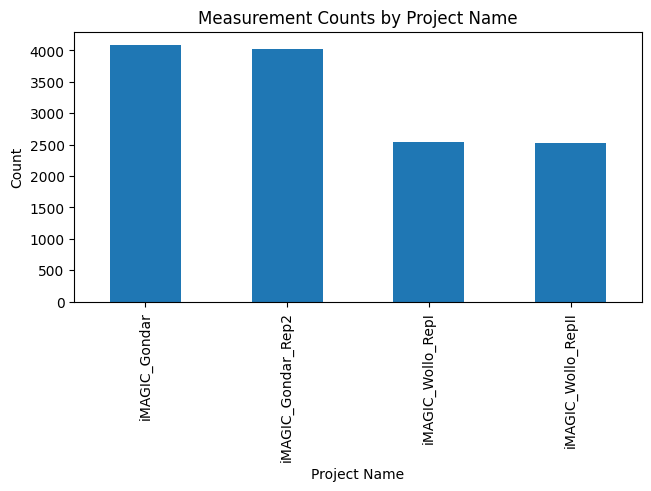

In [23]:
fig, ax = plt.subplots(layout="constrained")
df["project_name"].value_counts().sort_index().plot.bar(ax=ax)
ax.set_xlabel("Project Name")
ax.set_ylabel("Count")
ax.set_title("Measurement Counts by Project Name")
plt.show()

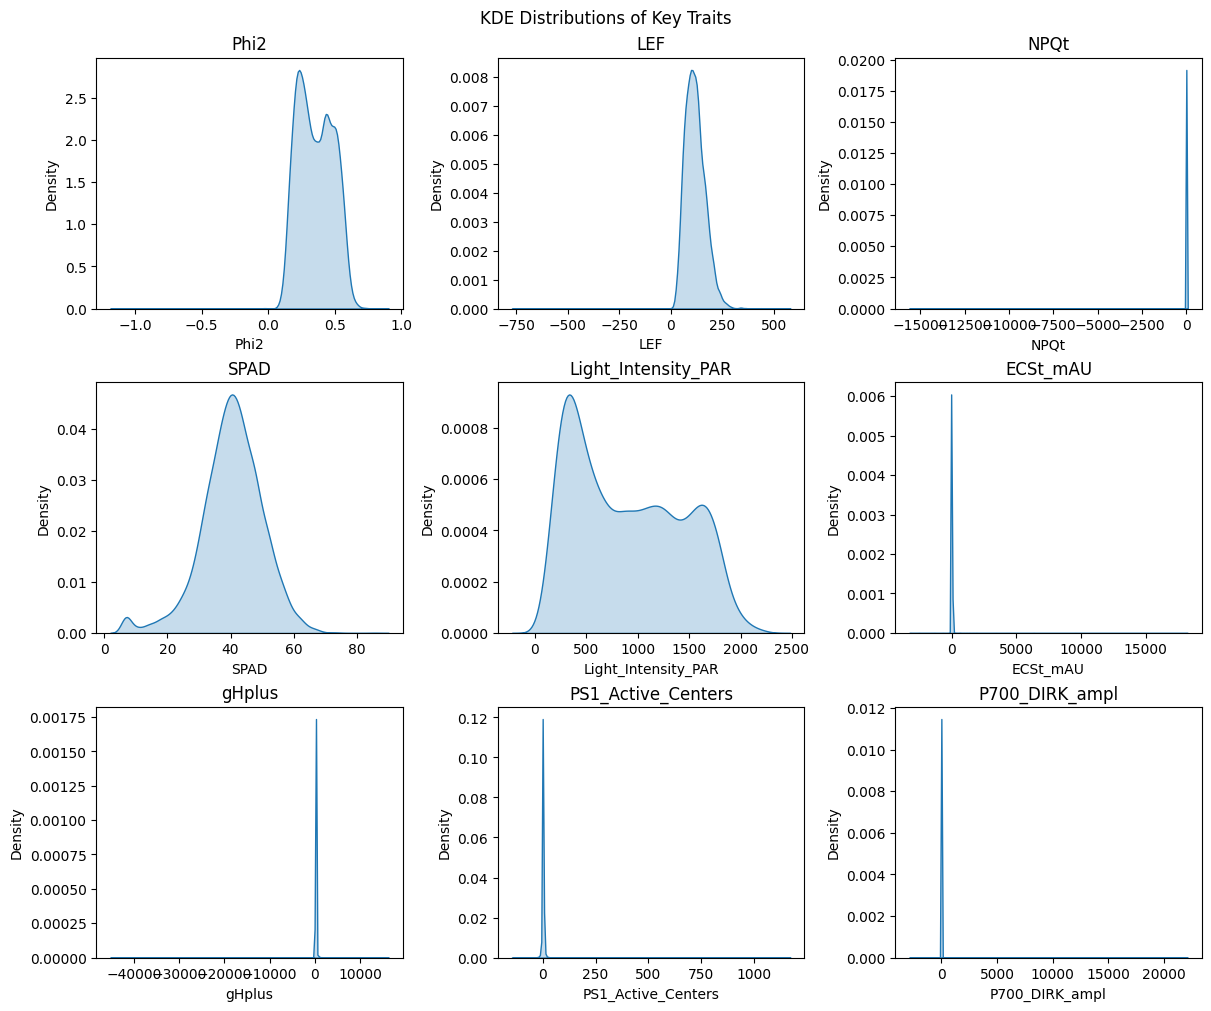

In [24]:
traits = [
    "Phi2",
    "LEF",
    "NPQt",
    "SPAD",
    "Light_Intensity_PAR",
    "ECSt_mAU",
    "gHplus",
    "PS1_Active_Centers",
    "P700_DIRK_ampl",
]

fig, axes = plt.subplots(3, 3, figsize=(12, 10), layout="constrained")
for ax, trait in zip(axes.flat, traits):
    sns.kdeplot(data=df, x=trait, ax=ax, fill=True)
    ax.set_title(trait)
fig.suptitle("KDE Distributions of Key Traits")
plt.show()

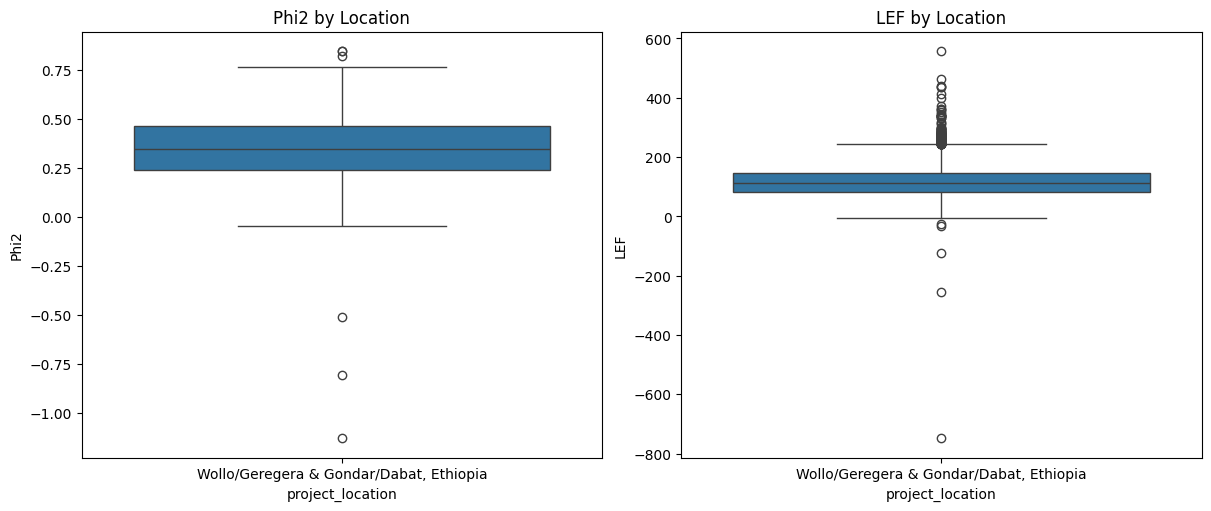

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

sns.boxplot(data=df, x="project_location", y="Phi2", ax=axes[0])
axes[0].set_title("Phi2 by Location")

sns.boxplot(data=df, x="project_location", y="LEF", ax=axes[1])
axes[1].set_title("LEF by Location")

plt.show()

In [26]:
df.describe()

,latitude,longitude,entry,block,matteo_plot,Phi2,PhiNPQ,PhiNO,NPQt,LEF,...,PS1_Active_Centers,PS1_Open_Centers,PS1_Over_Reduced_Centers,PS1_Oxidized_Centers,P700_DIRK_ampl,kP700,tP700,v_initial_P700,leaf_angle,leaf_thickness
count,13178.000000,13178.000000,9876.000000,9876.000000,9876.000000,13166.000000,13176.000000,13176.000000,13176.000000,13166.000000,...,13176.000000,13100.000000,13100.000000,13100.000000,13165.000000,13165.000000,1.316500e+04,13165.000000,13176.000000,13176.000000
mean,12.506505,38.146656,257.843763,3.972661,37.295261,0.353576,0.271718,0.373703,-0.101197,116.392879,...,1.536170,0.441466,0.178056,0.380469,2.157744,123.891591,-4.203082e+04,0.099607,6.815073,0.602284
std,0.610040,0.481281,149.138594,1.992660,21.259713,0.131850,0.369721,0.350066,135.626065,49.035873,...,14.868375,52.544173,115.442584,64.805189,214.609938,1591.269266,4.651228e+06,0.205254,4.076367,0.365214
min,11.733360,37.748515,1.000000,1.000000,1.000000,-1.129000,-11.354000,-22.846000,-15566.248000,-748.350000,...,-138.736000,-5029.956000,-7803.240000,-5313.458000,-2816.164110,-99432.696000,-5.331578e+08,-9.943270,0.000000,0.060000
25%,11.737042,37.749548,129.000000,2.000000,19.000000,0.241000,0.132000,0.263000,0.272000,80.762500,...,0.593750,0.043750,-0.475250,-0.002000,0.000370,124.152600,5.200000e-03,0.060773,3.941000,0.390000
50%,12.959837,37.834108,256.000000,4.000000,37.000000,0.346000,0.261000,0.351000,0.716000,111.510000,...,1.388000,0.349000,0.040000,0.468000,0.000660,154.050500,6.400000e-03,0.104901,6.159500,0.570000
75%,12.965200,38.754432,387.000000,6.000000,56.000000,0.463000,0.410000,0.457000,1.454250,145.745000,...,2.247000,0.721000,0.582000,0.985000,0.000950,189.993800,7.900000e-03,0.147915,8.912750,0.750000
max,13.092672,38.759233,516.000000,7.000000,74.000000,0.848000,23.333000,12.078000,14.885000,557.650000,...,1164.364000,2977.532000,10344.414000,4826.708000,22085.807860,33231.428100,2.850920e+06,7.206254,79.767000,4.320000


## Correlation Heatmap


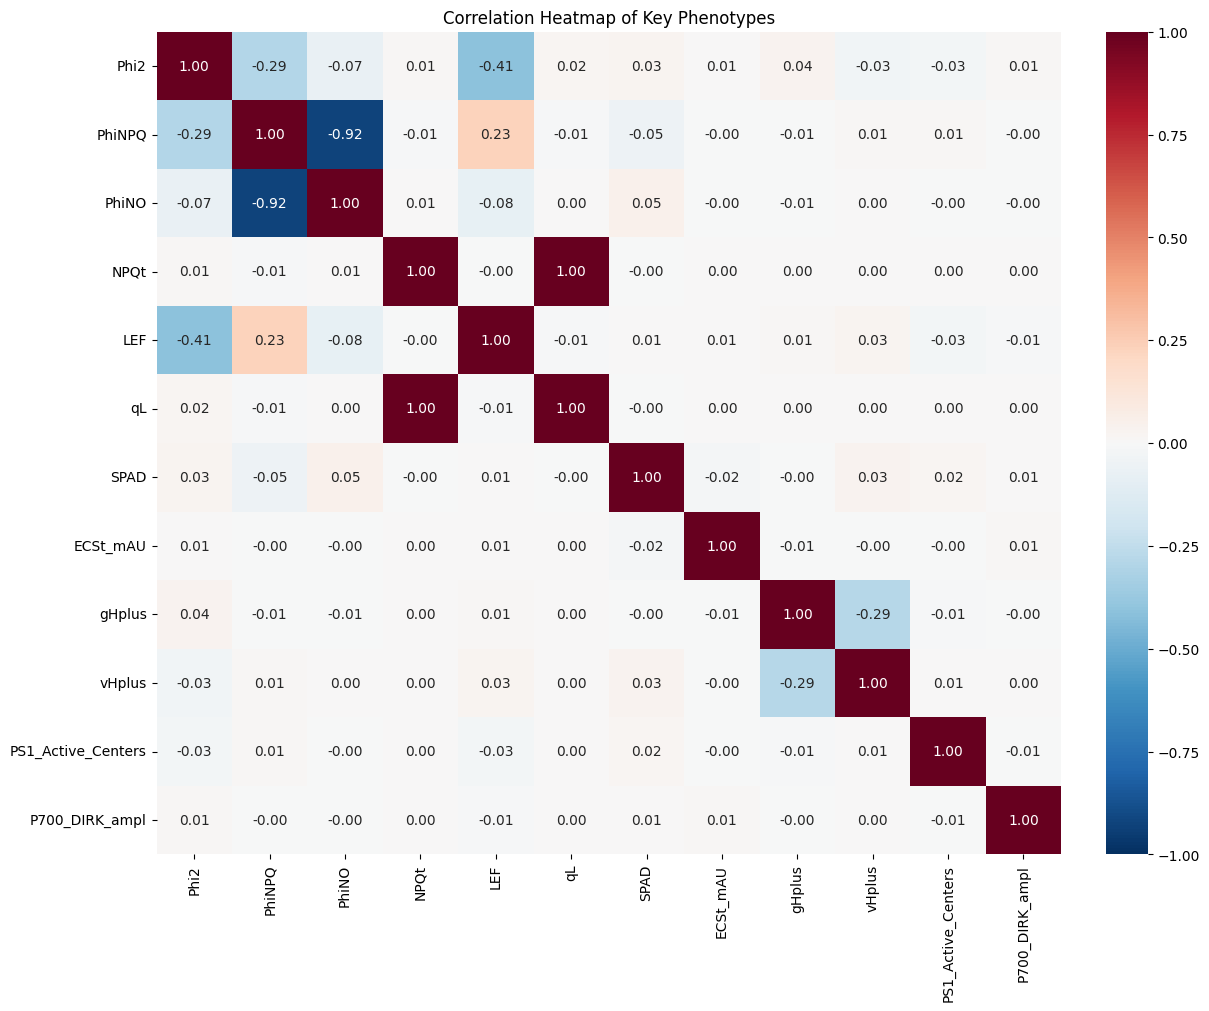

In [27]:
phenotype_cols = [
    "Phi2",
    "PhiNPQ",
    "PhiNO",
    "NPQt",
    "LEF",
    "qL",
    "SPAD",
    "ECSt_mAU",
    "gHplus",
    "vHplus",
    "PS1_Active_Centers",
    "P700_DIRK_ampl",
]

corr = df[phenotype_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10), layout="constrained")
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title("Correlation Heatmap of Key Phenotypes")
plt.show()

## Location Comparison


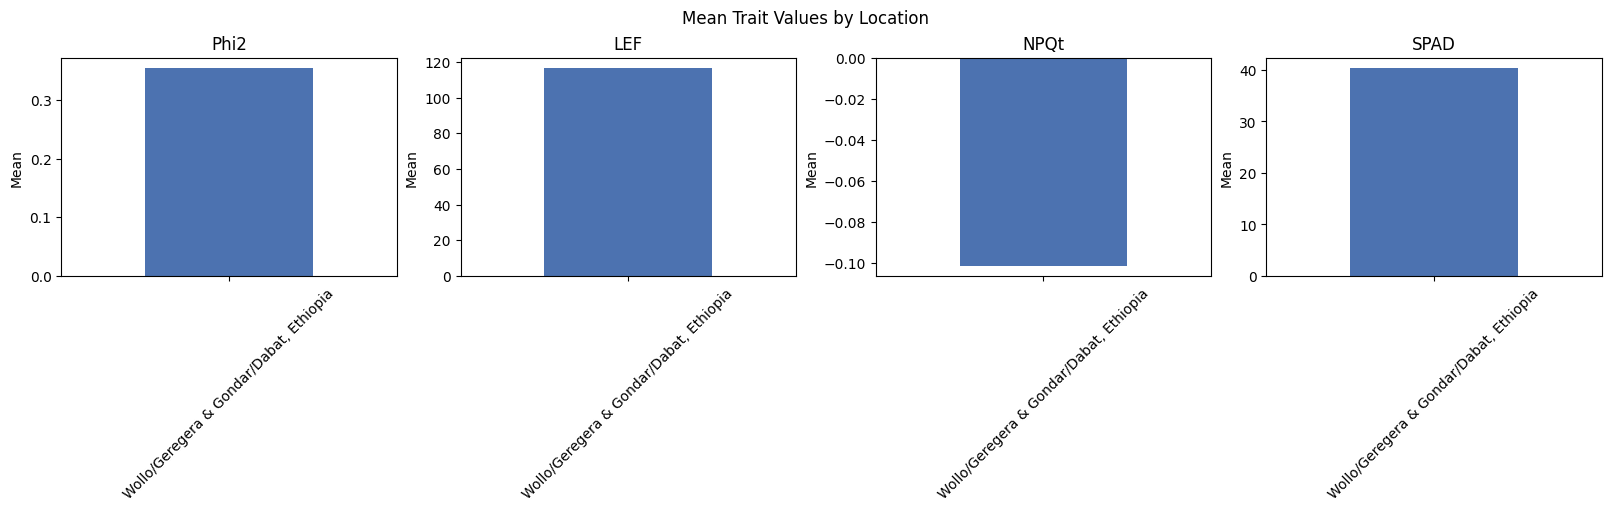

In [28]:
location_traits = ["Phi2", "LEF", "NPQt", "SPAD"]

location_means = df.groupby("project_location")[location_traits].mean()

fig, axes = plt.subplots(1, 4, figsize=(16, 5), layout="constrained")
for ax, trait in zip(axes.flat, location_traits):
    location_means[trait].plot.bar(ax=ax, color=["#4c72b0", "#dd8452"])
    ax.set_title(trait)
    ax.set_xlabel("")
    ax.set_ylabel("Mean")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Mean Trait Values by Location")
plt.show()

## Heritability


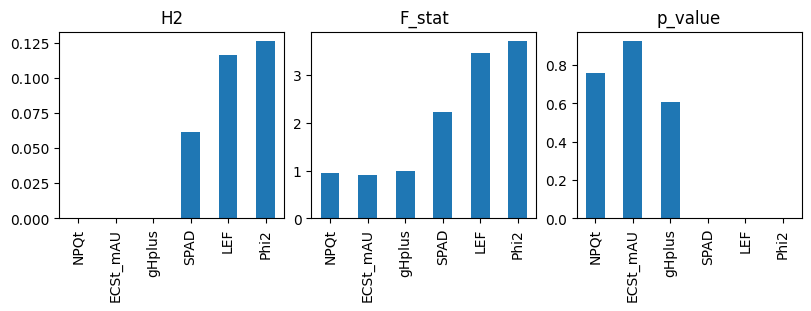

,H2,F_stat,p_value
NPQt,0.000000,0.953960,7.599406e-01
ECSt_mAU,0.000000,0.907761,9.277371e-01
gHplus,0.000000,0.981179,6.081028e-01
SPAD,0.061312,2.225997,4.114245e-45
LEF,0.116072,3.464665,4.230113e-121
Phi2,0.126580,3.720119,4.468796e-138


In [29]:
from src import drop_na_multiple, heritability, heritability_with_covariates

df_g = df.dropna(subset=["genotype"])

heritability_traits = ["Phi2", "LEF", "NPQt", "SPAD", "ECSt_mAU", "gHplus"]
data = df_g[heritability_traits]
gtype = df_g["genotype"]

data, gtype = drop_na_multiple(data, gtype)

# Filter genotypes with more than 3 entries
gtype_counts = gtype.value_counts()
keep = gtype_counts[gtype_counts > 3].index
mask = gtype.isin(keep)
data = data[mask]
gtype = gtype[mask]

h2 = heritability(data=data, gtype=gtype)
h2.plot()
plt.show()
h2.as_frame()

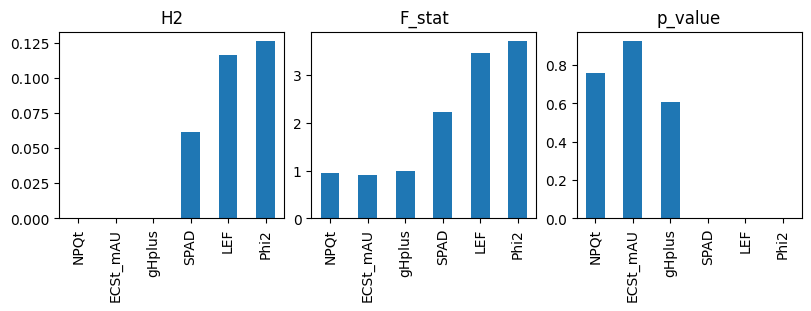

,H2,F_stat,p_value
NPQt,0.000000,0.953960,7.599406e-01
ECSt_mAU,0.000000,0.907761,9.277371e-01
gHplus,0.000000,0.981179,6.081028e-01
SPAD,0.061323,2.225997,4.114245e-45
LEF,0.116088,3.464665,4.230113e-121
Phi2,0.126597,3.720119,4.468796e-138


In [30]:
env_factors = df_g.loc[data.index, ["project_location"]].apply(
    lambda c: c.factorize()[0]
)

h2_cov = heritability_with_covariates(data=data, env_factors=env_factors, gtype=gtype)
h2_cov.plot()
plt.show()
h2_cov.as_frame()